In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Load the dataset
df = pd.read_csv("Sleep_Health_and_Lifestyle_DS.csv")


# Convert Blood Pressure to numerical columns
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.extract(r'(\d+)/(\d+)').astype(float)

df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140.0,95.0
1,2,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea,140.0,95.0
2,3,Male,31,Doctor,6.1,6,30,8,Normal,125/80,72,5000,NaN,125.0,80.0
3,4,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea,140.0,95.0
4,5,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140.0,95.0


In [3]:
def basic_info(data):
    # Display first few rows of the dataset
    display(data.head())
    
    # Display dataset information
    print('\nDataset Information:\n')
    data.info()
    
    # Display summary statistics
    print('\nSummary Statistics:\n')
    display(data.describe())

    # Display missing values
    print('\nMissing Values:\n')
    print(data.isnull().sum())

basic_info(df)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP
0,1,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140.0,95.0
1,2,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea,140.0,95.0
2,3,Male,31,Doctor,6.1,6,30,8,Normal,125/80,72,5000,NaN,125.0,80.0
3,4,Female,50,Nurse,6.0,6,90,8,Overweight,140/95,75,10000,Sleep Apnea,140.0,95.0
4,5,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,140.0,95.0



Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                50000 non-null  int64  
 1   Gender                   50000 non-null  object 
 2   Age                      50000 non-null  int64  
 3   Occupation               50000 non-null  object 
 4   Sleep Duration           50000 non-null  float64
 5   Quality of Sleep         50000 non-null  int64  
 6   Physical Activity Level  50000 non-null  int64  
 7   Stress Level             50000 non-null  int64  
 8   BMI Category             50000 non-null  object 
 9   Blood Pressure           50000 non-null  object 
 10  Heart Rate               50000 non-null  int64  
 11  Daily Steps              50000 non-null  int64  
 12  Sleep Disorder           20721 non-null  object 
 13  Systolic_BP              50000 non-null  float64
 14 

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,42.182840,7.131856,7.312840,59.176720,5.38504,70.166080,6817.234000,128.553680,84.650080
std,14433.901067,8.660168,0.794447,1.195056,20.800743,1.77195,4.129382,1615.479924,7.738121,6.153503
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.00000,65.000000,3000.000000,115.000000,75.000000
25%,12500.750000,35.000000,6.400000,6.000000,45.000000,4.00000,68.000000,5600.000000,125.000000,80.000000
50%,25000.500000,43.000000,7.200000,7.000000,60.000000,5.00000,70.000000,7000.000000,130.000000,85.000000
75%,37500.250000,50.000000,7.800000,8.000000,75.000000,7.00000,72.000000,8000.000000,135.000000,90.000000
max,50000.000000,59.000000,8.500000,9.000000,90.000000,8.00000,86.000000,10000.000000,142.000000,95.000000



Missing Values:

Person ID                      0
Gender                         0
Age                            0
Occupation                     0
Sleep Duration                 0
Quality of Sleep               0
Physical Activity Level        0
Stress Level                   0
BMI Category                   0
Blood Pressure                 0
Heart Rate                     0
Daily Steps                    0
Sleep Disorder             29279
Systolic_BP                    0
Diastolic_BP                   0
dtype: int64


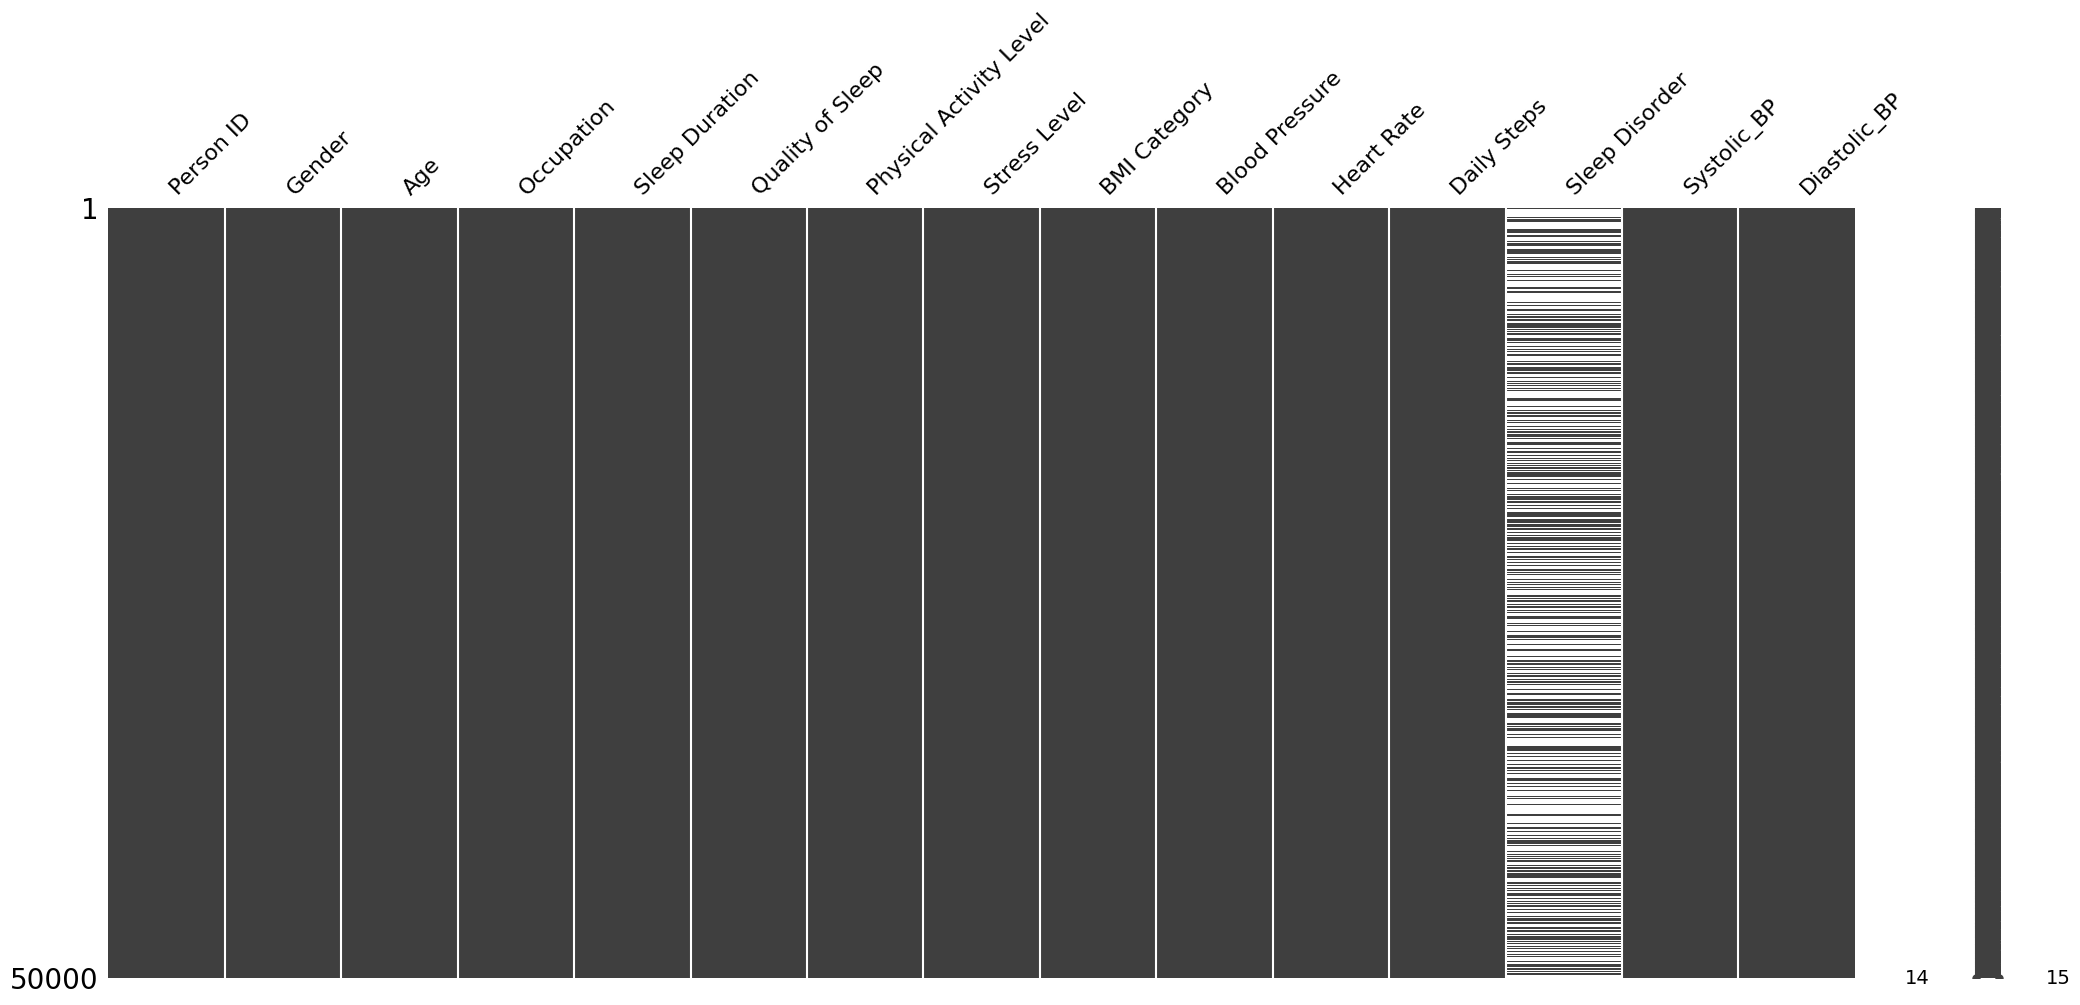

In [4]:
# Visualize missing data
msno.matrix(df)
plt.show()

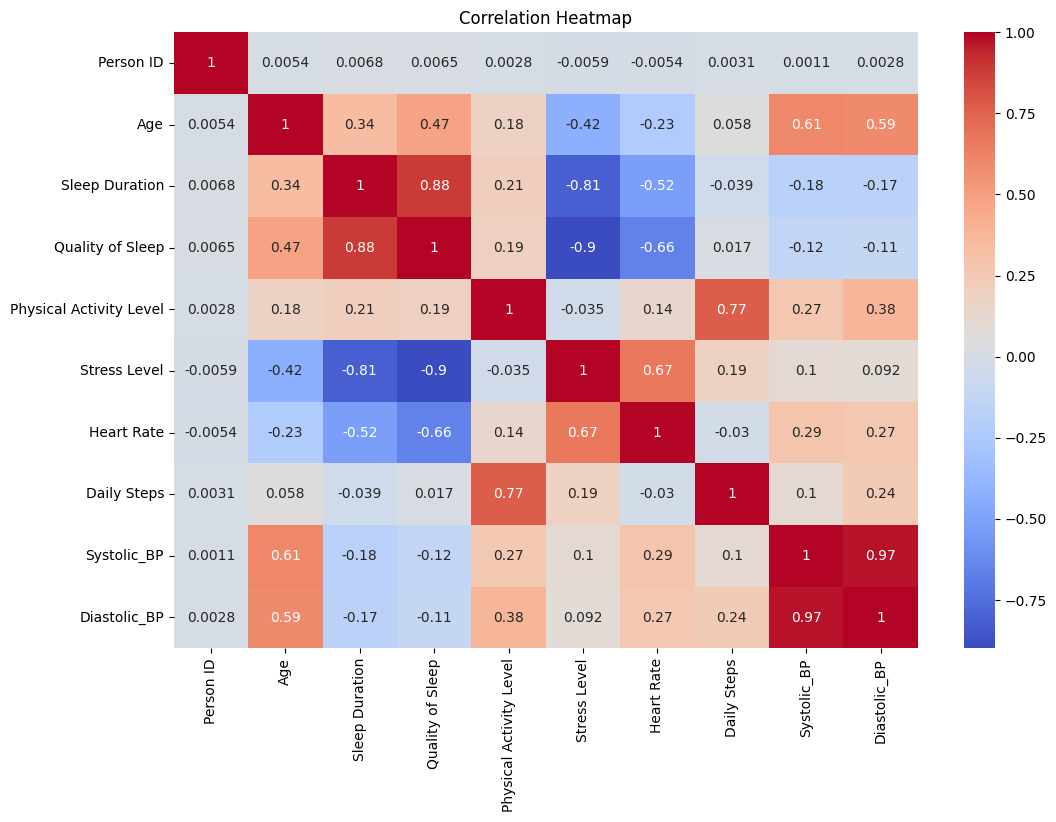

In [5]:
# Generate a heatmap of correlations, considering only numerical columns
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

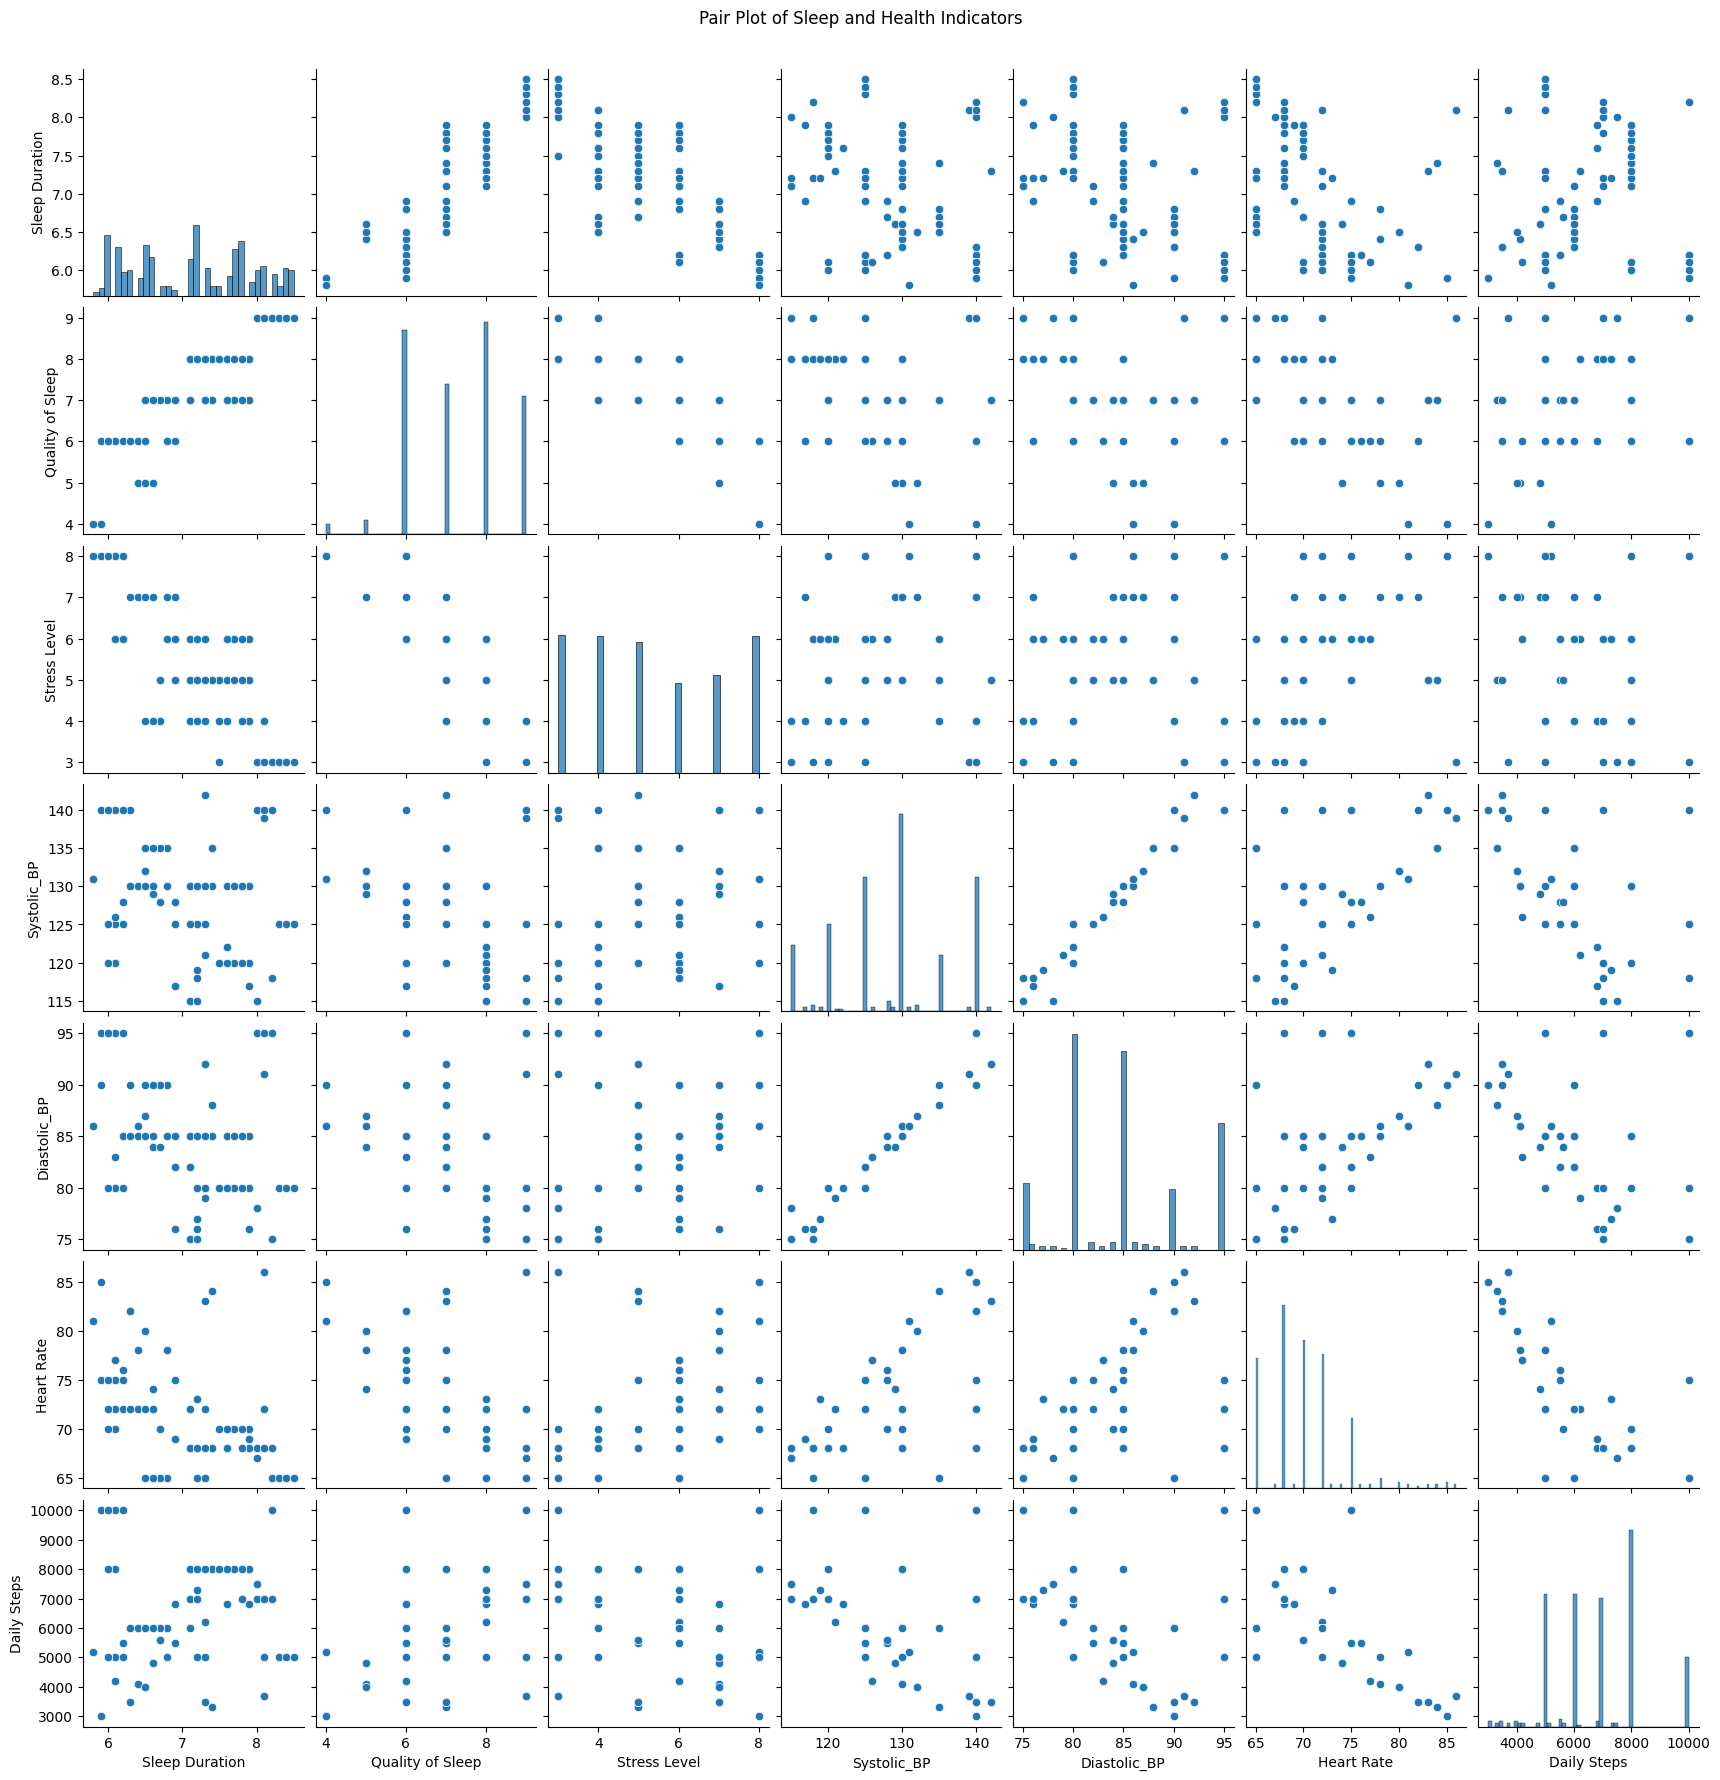

In [6]:

# Plotting Pair Plot
sns.pairplot(df[['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']])
plt.suptitle('Pair Plot of Sleep and Health Indicators', y=1.02)
plt.show()

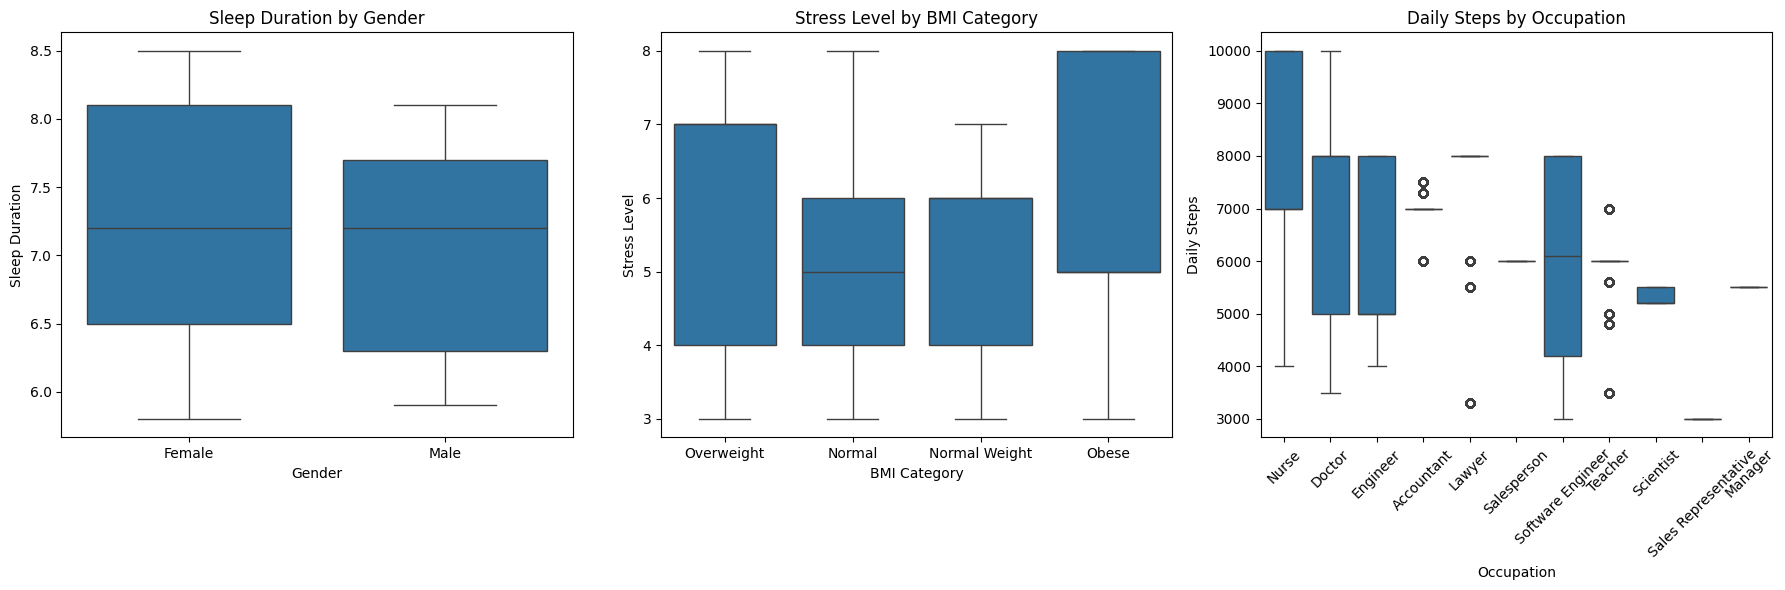

In [7]:
# Plotting Box Plots
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='Gender', y='Sleep Duration', data=df)
plt.title('Sleep Duration by Gender')

plt.subplot(1, 3, 2)
sns.boxplot(x='BMI Category', y='Stress Level', data=df)
plt.title('Stress Level by BMI Category')

plt.subplot(1, 3, 3)
sns.boxplot(x='Occupation', y='Daily Steps', data=df)
plt.title('Daily Steps by Occupation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


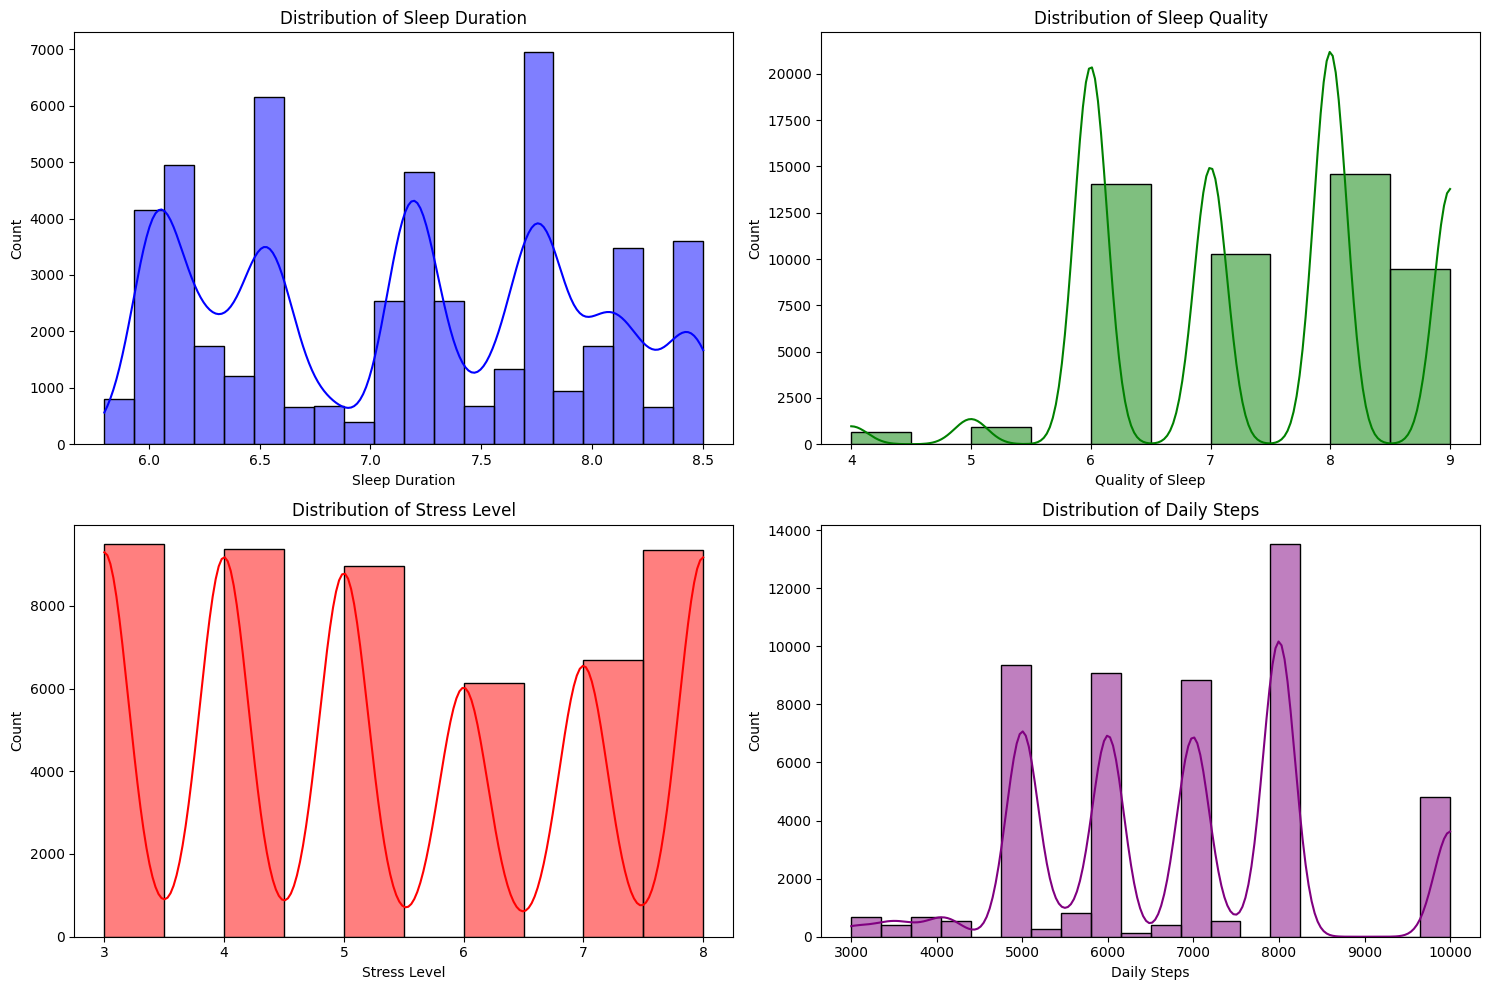

In [8]:
plt.figure(figsize=(15, 10))


plt.subplot(2, 2, 1)
sns.histplot(df["Sleep Duration"], bins=20, kde=True, color="blue")
plt.title("Distribution of Sleep Duration")


plt.subplot(2, 2, 2)
sns.histplot(df["Quality of Sleep"], bins=10, kde=True, color="green")
plt.title("Distribution of Sleep Quality")

plt.subplot(2, 2, 3)
sns.histplot(df["Stress Level"], bins=10, kde=True, color="red")
plt.title("Distribution of Stress Level")


plt.subplot(2, 2, 4)
sns.histplot(df["Daily Steps"], bins=20, kde=True, color="purple")
plt.title("Distribution of Daily Steps")

plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_33788\1198489327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Gender", y="Sleep Duration", data=df, palette="Set2")


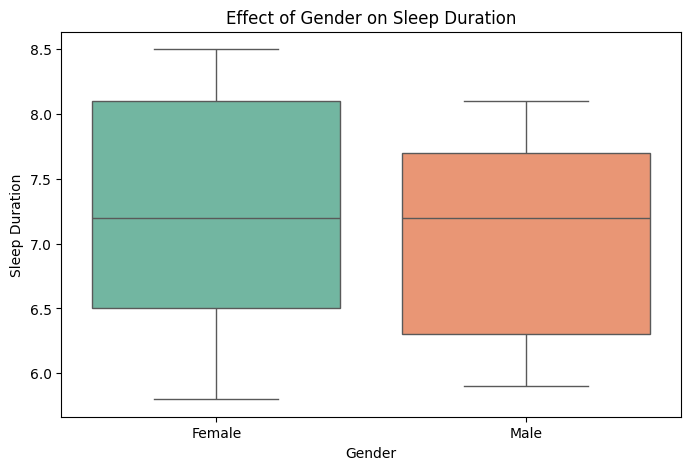

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Gender", y="Sleep Duration", data=df, palette="Set2")
plt.title("Effect of Gender on Sleep Duration")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_33788\1633901687.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="BMI Category", y="Quality of Sleep", data=df, palette="Set3")


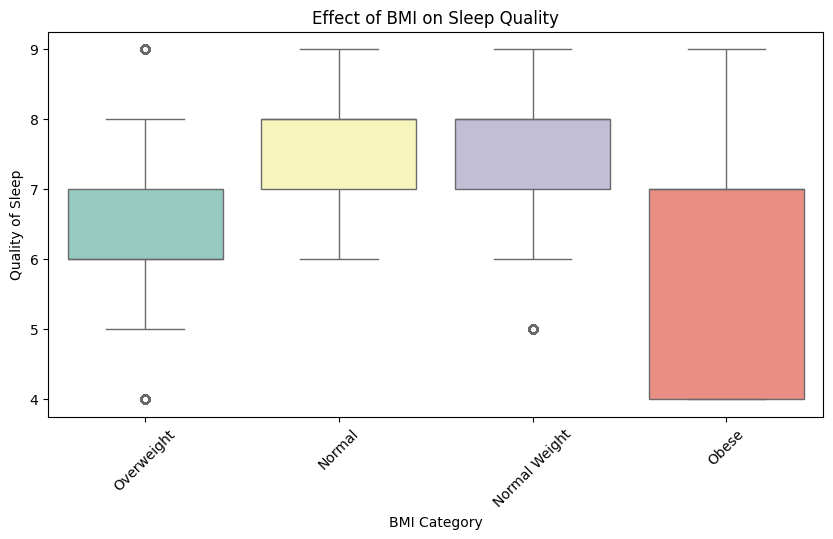

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="BMI Category", y="Quality of Sleep", data=df, palette="Set3")
plt.xticks(rotation=45)
plt.title("Effect of BMI on Sleep Quality")
plt.show()

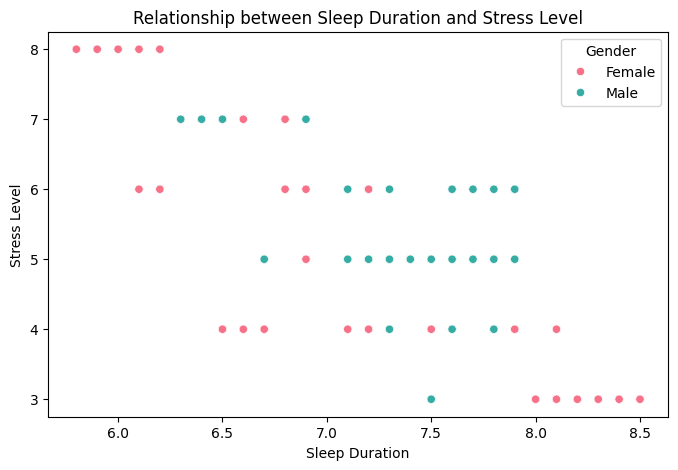

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Sleep Duration", y="Stress Level", data=df, hue="Gender", palette="husl")
plt.title("Relationship between Sleep Duration and Stress Level")
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_33788\2221107890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sleep Disorder", data=df, palette="pastel")


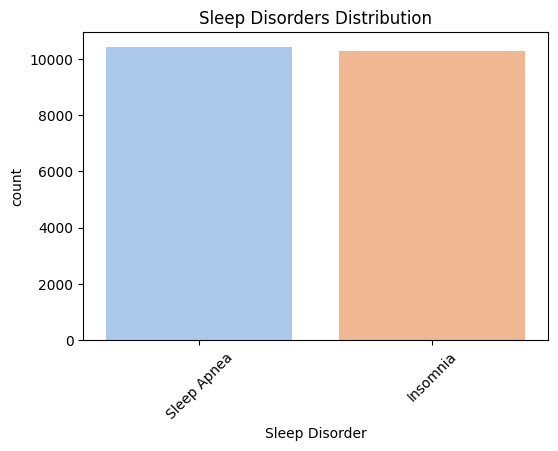

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Sleep Disorder", data=df, palette="pastel")
plt.title("Sleep Disorders Distribution")
plt.xticks(rotation=45)
plt.show()
